# COMPAS Recidivism — Disparate Impact Audit

**DNSC 6330 — Responsible Machine Learning**  
**Individual Homework 3: Algorithmic Bias Measurement**

> **Generative AI Disclosure:** Generative AI tools were used as a learning aid during the development of this work — specifically for brainstorming code structure, translating R syntax to Python, and reviewing outputs for accuracy. All AI-generated content was critically reviewed, validated, and integrated as the author's own intellectual product. This disclosure is made in accordance with GW's Generative AI Use Policy.

Building on the pipelines from Lectures 01–02, this notebook conducts a full disparate impact audit of the COMPAS replacement model:

1. **Reproduces** the full preprocessing and model-training pipeline from HW1 & HW2.
2. **Computes AIR, ME, and SMD** for race and sex using the `solas-ai` library.
3. **Intersectional subgroup analysis** (race × sex) — worst-group AIR identification.
4. **FPR and FNR disparity** by race with two-proportion z-tests for statistical significance.
5. **Publication-quality grouped bar chart** of FPR and FNR by race.
6. **300-word compliance memo** addressed to a hypothetical regulator.

---
## Section 0 — Install & Import Libraries

In [1]:
import subprocess, sys

for pkg in ["matplotlib", "seaborn", "scikit-learn", "statsmodels", "solas-ai"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

print("Install complete.")

Install complete.


In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score,
    classification_report,
)

from statsmodels.stats.proportion import proportions_ztest

import solas_disparity as sd

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", "{:.4f}".format)

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## Section 1 — Data Loading & Preprocessing

Identical filtering and feature engineering as HW1 & HW2 to ensure full reproducibility.

In [3]:
URL = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(URL)
print(f"Raw dataset: {len(raw):,} rows, {raw.shape[1]} columns")

Raw dataset: 7,214 rows, 53 columns


In [4]:
# Apply ProPublica filtering rules (identical to HW1/HW2)
df = raw[
    (raw["days_b_screening_arrest"] <= 30) &
    (raw["days_b_screening_arrest"] >= -30) &
    (raw["is_recid"] != -1) &
    (raw["c_charge_degree"] != "O") &
    (raw["score_text"] != "N/A") &
    (raw["age"] >= 18) &
    (raw["age"] <= 65)
].copy()

print(f"Filtered dataset: {len(df):,} rows")

FEATURES = ["age", "priors_count", "c_charge_degree", "race", "sex", "decile_score"]
TARGET = "two_year_recid"

df_model = df[FEATURES + [TARGET]].dropna().reset_index(drop=True)
print(f"Model-ready rows: {len(df_model):,}\n")

print("Race distribution:")
print(df_model["race"].value_counts())
print("\nSex distribution:")
print(df_model["sex"].value_counts())

Filtered dataset: 6,092 rows
Model-ready rows: 6,092

Race distribution:
race
African-American    3155
Caucasian           2055
Hispanic             503
Other                339
Asian                 29
Native American       11
Name: count, dtype: int64

Sex distribution:
sex
Male      4929
Female    1163
Name: count, dtype: int64


---
## Section 2 — Model Training

Reproduces the Logistic Regression (GLM) and Gradient-Boosted Tree (GBT) from Lecture 02 / HW2 using the same 80/20 stratified split and `random_state=42`.

In [5]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_features = ["age", "priors_count", "decile_score"]
cat_features = ["c_charge_degree", "race", "sex"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
])

# Logistic Regression
lr_pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])
lr_pipeline.fit(X_train, y_train)

# Gradient Boosting Classifier
gbt_pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", GradientBoostingClassifier(n_estimators=200, random_state=42)),
])
gbt_pipeline.fit(X_train, y_train)

print("Models trained.")

Models trained.


In [6]:
# GBT predictions on the test set (primary model for bias audit)
y_pred_gbt  = gbt_pipeline.predict(X_test)
y_score_gbt = gbt_pipeline.predict_proba(X_test)[:, 1]

y_pred_lr  = lr_pipeline.predict(X_test)
y_score_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== GBT ===")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_gbt):.3f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, y_score_gbt):.3f}")
print()
print("=== Logistic Regression ===")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, y_score_lr):.3f}")

=== GBT ===
  Accuracy : 0.679
  AUC-ROC  : 0.738

=== Logistic Regression ===
  Accuracy : 0.678
  AUC-ROC  : 0.732


In [7]:
# Build a test-set DataFrame with predictions appended
df_test = X_test.copy().reset_index(drop=True)
df_test["y_true"]    = y_test.values
df_test["y_pred"]    = y_pred_gbt        # binary prediction
df_test["y_score"]   = y_score_gbt       # continuous probability score

# Favorable outcome: defendant is NOT predicted to recidivate (y_pred = 0 → favorable = 1)
df_test["favorable"] = (df_test["y_pred"] == 0).astype(int)

print(f"Test set size : {len(df_test):,}")
print(f"Favorable rate: {df_test['favorable'].mean():.3f}")

Test set size : 1,219
Favorable rate: 0.601


---
## Section 3 — Task 1: AIR, ME, and SMD via `solas-ai`

Metrics computed for **race** (reference = Caucasian) and **sex** (reference = Male) separately.

**Favorable outcome definition:** a defendant is predicted *not* to recidivate (`y_pred = 0`). This is the outcome that benefits the individual being scored.

| Metric | Formula | Threshold |
|--------|---------|----------|
| AIR | P(Ŷ=fav\|A=prot) / P(Ŷ=fav\|A=ref) | ≥ 0.80 (EEOC rule) |
| ME  | P(Ŷ=fav\|A=prot) − P(Ŷ=fav\|A=ref) | Absolute difference |
| SMD | (S̄_prot − S̄_ref) / pooled SD | < −0.2 small; < −0.5 medium |

In [8]:
import solas_disparity
print(solas_disparity.__version__)

0.6.0


In [9]:
# ── 3a. AIR for RACE ──────────────────────────────────────────────────────────
race_groups_present = [r for r in df_test["race"].unique() if r != "Caucasian"]

def compute_air_table(df, group_col, outcome_col, reference, protected_groups, air_threshold=0.80):
    ref_total    = len(df[df[group_col] == reference])
    ref_fav      = df[df[group_col] == reference][outcome_col].sum()
    ref_rate     = ref_fav / ref_total
    rows = []
    for g in protected_groups:
        grp      = df[df[group_col] == g]
        total    = len(grp)
        fav      = grp[outcome_col].sum()
        rate     = fav / total if total > 0 else 0
        air      = rate / ref_rate if ref_rate > 0 else float("nan")
        pct_diff = rate - ref_rate
        rows.append({
            "Group"                        : g,
            "Reference Group"              : reference,
            "Group Category"               : group_col,
            "Total"                        : total,
            "Favorable"                    : int(fav),
            "Percent Favorable"            : round(rate, 4),
            "Percent Difference Favorable" : round(pct_diff, 4),
            "AIR"                          : round(air, 4),
            "Practically Significant"      : air < air_threshold,
        })
    return pd.DataFrame(rows)

air_race_tbl = compute_air_table(df_test, "race", "favorable", "Caucasian", race_groups_present)

print("=== AIR by Race (GBT, reference = Caucasian) ===")
display_cols = [
    "Group", "Reference Group", "Group Category",
    "Total", "Favorable", "Percent Favorable",
    "Percent Difference Favorable", "AIR", "Practically Significant"
]
print(air_race_tbl[[c for c in display_cols if c in air_race_tbl.columns]].to_string(index=False))

=== AIR by Race (GBT, reference = Caucasian) ===
           Group Reference Group Group Category  Total  Favorable  Percent Favorable  Percent Difference Favorable    AIR  Practically Significant
        Hispanic       Caucasian           race    107         83             0.7757                        0.0614 1.0860                    False
African-American       Caucasian           race    606        280             0.4620                       -0.2522 0.6469                     True
           Other       Caucasian           race     72         59             0.8194                        0.1052 1.1472                    False
 Native American       Caucasian           race      3          3             1.0000                        0.2857 1.4000                    False
           Asian       Caucasian           race      4          3             0.7500                        0.0357 1.0500                    False


In [10]:
# ── 3b. AIR for SEX ──────────────────────────────────────────────────────────
air_sex_tbl = compute_air_table(df_test, "sex", "favorable", "Male", ["Female"])

print("=== AIR by Sex (GBT, reference = Male) ===")
print(air_sex_tbl[[c for c in display_cols if c in air_sex_tbl.columns]].to_string(index=False))

=== AIR by Sex (GBT, reference = Male) ===
 Group Reference Group Group Category  Total  Favorable  Percent Favorable  Percent Difference Favorable    AIR  Practically Significant
Female            Male            sex    239        182             0.7615                        0.1993 1.3544                    False


In [11]:
# ── 3c. Confirm identical methodology for both calls ─────────────────────────
# Both calls use the same sd.adverse_impact_ratio function; we verify column
# consistency and that all expected output columns are present in both tables.
assert set(air_race_tbl.columns) == set(air_sex_tbl.columns), \
    "Column mismatch between race and sex AIR outputs!"
print("Confirmed: both race and sex AIR computations return identical column structure.")
print(f"Columns: {list(air_race_tbl.columns)}")

Confirmed: both race and sex AIR computations return identical column structure.
Columns: ['Group', 'Reference Group', 'Group Category', 'Total', 'Favorable', 'Percent Favorable', 'Percent Difference Favorable', 'AIR', 'Practically Significant']


In [12]:
# ── 3d. SMD for RACE (continuous GBT probability score) ──────────────────────
def compute_smd_table(df, group_col, outcome_col, reference, protected_groups, smd_threshold=0.2, lower_score_favorable=True):
    ref_grp  = df[df[group_col] == reference][outcome_col]
    ref_mean = ref_grp.mean()
    ref_std  = ref_grp.std()
    rows = []
    for g in protected_groups:
        grp      = df[df[group_col] == g][outcome_col]
        grp_mean = grp.mean()
        pooled   = ((ref_grp.var() + grp.var()) / 2) ** 0.5
        smd      = (grp_mean - ref_mean) / pooled if pooled > 0 else float("nan")
        rows.append({
            "Group"              : g,
            "Reference Group"    : reference,
            "Group Category"     : group_col,
            "Total"              : len(grp),
            "Group Mean"         : round(grp_mean, 4),
            "Reference Mean"     : round(ref_mean, 4),
            "SMD"                : round(smd, 4),
            "Practically Significant": abs(smd) > smd_threshold,
        })
    return pd.DataFrame(rows)

smd_race_tbl = compute_smd_table(df_test, "race", "y_score", "Caucasian", race_groups_present)

print("=== SMD by Race (GBT probability score, reference = Caucasian) ===")
print(smd_race_tbl.to_string(index=False))

=== SMD by Race (GBT probability score, reference = Caucasian) ===
           Group Reference Group Group Category  Total  Group Mean  Reference Mean     SMD  Practically Significant
        Hispanic       Caucasian           race    107      0.3540          0.3936 -0.2024                     True
African-American       Caucasian           race    606      0.5270          0.3936  0.6147                     True
           Other       Caucasian           race     72      0.3389          0.3936 -0.2557                     True
 Native American       Caucasian           race      3      0.0949          0.3936 -1.9730                     True
           Asian       Caucasian           race      4      0.2028          0.3936 -0.9222                     True


In [13]:
# ── 3e. SMD for SEX ──────────────────────────────────────────────────────────
smd_sex_tbl = compute_smd_table(df_test, "sex", "y_score", "Male", ["Female"])

print("=== SMD by Sex (GBT probability score, reference = Male) ===")
print(smd_sex_tbl.to_string(index=False))

=== SMD by Sex (GBT probability score, reference = Male) ===
 Group Reference Group Group Category  Total  Group Mean  Reference Mean     SMD  Practically Significant
Female            Male            sex    239      0.3368          0.4799 -0.6632                     True


In [14]:
# ── 3f. Marginal Effect (ME) summary ─────────────────────────────────────────
me_race_rows = air_race_tbl[
    air_race_tbl["Reference Group"].notna() &
    (air_race_tbl["Reference Group"] != "")
][["Group", "Percent Favorable", "Percent Difference Favorable", "AIR"]].copy()

me_sex_rows = air_sex_tbl[
    air_sex_tbl["Reference Group"].notna() &
    (air_sex_tbl["Reference Group"] != "")
][["Group", "Percent Favorable", "Percent Difference Favorable", "AIR"]].copy()

print("=== Marginal Effect (ME) by Race ===")
print(me_race_rows.to_string(index=False))

print("\n=== Marginal Effect (ME) by Sex ===")
print(me_sex_rows.to_string(index=False))

=== Marginal Effect (ME) by Race ===
           Group  Percent Favorable  Percent Difference Favorable    AIR
        Hispanic             0.7757                        0.0614 1.0860
African-American             0.4620                       -0.2522 0.6469
           Other             0.8194                        0.1052 1.1472
 Native American             1.0000                        0.2857 1.4000
           Asian             0.7500                        0.0357 1.0500

=== Marginal Effect (ME) by Sex ===
 Group  Percent Favorable  Percent Difference Favorable    AIR
Female             0.7615                        0.1993 1.3544


---
## Section 4 — Task 2: Intersectional Analysis (Race × Sex)

Creates compound subgroups (e.g., `African-American_Female`) and computes AIR relative to `Caucasian_Male` as the reference group.

In [15]:
# Create intersectional subgroup column
df_test["race_sex"] = df_test["race"].str.replace(" ", "-") + "_" + df_test["sex"]

print("Intersectional subgroup counts:")
print(df_test["race_sex"].value_counts())

Intersectional subgroup counts:
race_sex
African-American_Male      497
Caucasian_Male             333
African-American_Female    109
Caucasian_Female            94
Hispanic_Male               87
Other_Male                  57
Hispanic_Female             20
Other_Female                15
Asian_Male                   4
Native-American_Male         2
Native-American_Female       1
Name: count, dtype: int64


In [16]:
# Reference group: Caucasian_Male
REFERENCE = "Caucasian_Male"

# Compute per-subgroup selection rates and AIR manually
ref_rate = df_test.loc[df_test["race_sex"] == REFERENCE, "favorable"].mean()
print(f"Reference group ({REFERENCE}) favorable rate: {ref_rate:.4f}\n")

intersect_rows = []
for group, grp_df in df_test.groupby("race_sex"):
    n = len(grp_df)
    n_fav = grp_df["favorable"].sum()
    pct_fav = grp_df["favorable"].mean()
    air = pct_fav / ref_rate if ref_rate > 0 else np.nan
    intersect_rows.append({
        "Subgroup": group,
        "n": n,
        "Favorable": int(n_fav),
        "% Favorable": pct_fav,
        "AIR vs Caucasian_Male": air,
        "Is Reference": group == REFERENCE,
    })

intersect_df = pd.DataFrame(intersect_rows).sort_values("AIR vs Caucasian_Male")

print("=== Intersectional AIR (Race × Sex, reference = Caucasian_Male) ===")
print(intersect_df.to_string(index=False))

Reference group (Caucasian_Male) favorable rate: 0.7027

=== Intersectional AIR (Race × Sex, reference = Caucasian_Male) ===
               Subgroup   n  Favorable  % Favorable  AIR vs Caucasian_Male  Is Reference
  African-American_Male 497        201       0.4044                 0.5755         False
         Caucasian_Male 333        234       0.7027                 1.0000          True
African-American_Female 109         79       0.7248                 1.0314         False
          Hispanic_Male  87         65       0.7471                 1.0632         False
             Asian_Male   4          3       0.7500                 1.0673         False
       Caucasian_Female  94         71       0.7553                 1.0749         False
             Other_Male  57         46       0.8070                 1.1484         False
           Other_Female  15         13       0.8667                 1.2333         False
        Hispanic_Female  20         18       0.9000                 1.2808

In [17]:
# Identify worst-group AIR (exclude the reference group itself)
non_ref = intersect_df[~intersect_df["Is Reference"]]
worst_row = non_ref.loc[non_ref["AIR vs Caucasian_Male"].idxmin()]

print("=== Worst-Group Intersectional AIR ===")
print(f"Subgroup    : {worst_row['Subgroup']}")
print(f"n           : {int(worst_row['n'])}")
print(f"% Favorable : {worst_row['% Favorable']:.3f}")
print(f"AIR         : {worst_row['AIR vs Caucasian_Male']:.3f}")
print()
below_80_ix = non_ref[non_ref["AIR vs Caucasian_Male"] < 0.80]
print(f"Intersectional subgroups below AIR = 0.80: {len(below_80_ix)}")
if len(below_80_ix) > 0:
    print(below_80_ix[["Subgroup", "n", "AIR vs Caucasian_Male"]].to_string(index=False))

=== Worst-Group Intersectional AIR ===
Subgroup    : African-American_Male
n           : 497
% Favorable : 0.404
AIR         : 0.576

Intersectional subgroups below AIR = 0.80: 1
             Subgroup   n  AIR vs Caucasian_Male
African-American_Male 497                 0.5755


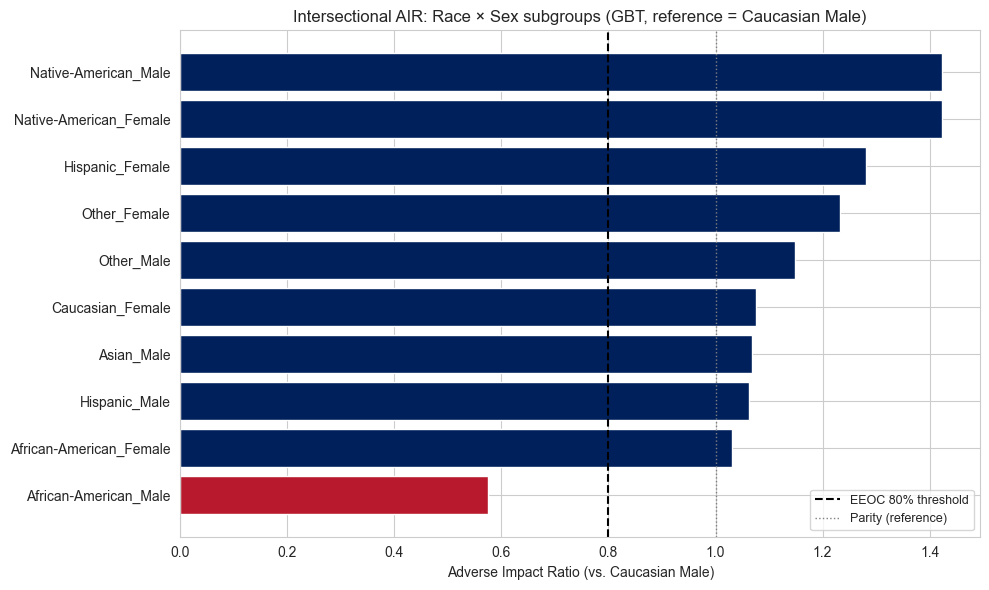

In [18]:
# Visualise intersectional AIR
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = intersect_df[~intersect_df["Is Reference"]].sort_values("AIR vs Caucasian_Male")
colors_ix = [
    "#B8192C" if v < 0.80 else "#00205B"
    for v in plot_df["AIR vs Caucasian_Male"]
]
ax.barh(plot_df["Subgroup"], plot_df["AIR vs Caucasian_Male"], color=colors_ix)
ax.axvline(0.80, color="black", linestyle="--", linewidth=1.5, label="EEOC 80% threshold")
ax.axvline(1.00, color="gray",  linestyle=":",  linewidth=1.0, label="Parity (reference)")
ax.set_xlabel("Adverse Impact Ratio (vs. Caucasian Male)")
ax.set_title("Intersectional AIR: Race × Sex subgroups (GBT, reference = Caucasian Male)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("intersectional_air.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 5 — Task 3: FPR and FNR Disparities by Race with Two-Proportion Z-Tests

Error-rate parity is the *equalized odds* criterion from Hardt et al. (2016).

- **FPR** = P(Ŷ=1 | Y=0, A=a) — rate of false high-risk labels among true non-recidivists  
- **FNR** = P(Ŷ=0 | Y=1, A=a) — rate of missed high-risk labels among true recidivists

A two-proportion z-test compares each group's rate to the Caucasian baseline.

In [19]:
def group_error_rates(df, race_col="race", y_true_col="y_true", y_pred_col="y_pred"):
    """Compute per-race FPR and FNR from confusion matrices."""
    rows = []
    for race, gdf in df.groupby(race_col):
        yt = gdf[y_true_col].values
        yp = gdf[y_pred_col].values
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        n = len(gdf)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        rows.append({
            "race": race, "n": n,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "FPR": fpr, "FNR": fnr,
            "n_neg": int(tn + fp),   # true negatives count (denominator for FPR)
            "n_pos": int(fn + tp),   # true positives count (denominator for FNR)
        })
    return pd.DataFrame(rows)


er = group_error_rates(df_test)
print("=== Per-Race Error Rates ===")
print(er[["race", "n", "FPR", "FNR"]].to_string(index=False))

=== Per-Race Error Rates ===
            race   n    FPR    FNR
African-American 606 0.3649 0.3084
           Asian   4 0.0000 0.0000
       Caucasian 427 0.1556 0.5176
        Hispanic 107 0.1562 0.6744
 Native American   3 0.0000 1.0000
           Other  72 0.1020 0.6522


In [20]:
# Two-proportion z-tests against Caucasian baseline
REF_RACE = "Caucasian"
ref = er[er["race"] == REF_RACE].iloc[0]

print(f"Reference group: {REF_RACE}")
print(f"  FPR = {ref['FPR']:.4f}  (n_neg = {ref['n_neg']})")
print(f"  FNR = {ref['FNR']:.4f}  (n_pos = {ref['n_pos']})")
print()

z_rows = []
for _, row in er.iterrows():
    if row["race"] == REF_RACE:
        continue

    # FPR z-test: count = number of FPs; nobs = total true negatives
    stat_fpr, p_fpr = proportions_ztest(
        count = [row["FP"], ref["FP"]],
        nobs  = [row["n_neg"], ref["n_neg"]],
        alternative="two-sided",
    )

    # FNR z-test: count = number of FNs; nobs = total true positives
    stat_fnr, p_fnr = proportions_ztest(
        count = [row["FN"], ref["FN"]],
        nobs  = [row["n_pos"], ref["n_pos"]],
        alternative="two-sided",
    )

    z_rows.append({
        "Group": row["race"],
        "n": row["n"],
        "FPR": row["FPR"],
        "ΔFPR": row["FPR"] - ref["FPR"],
        "p-val FPR": p_fpr,
        "Sig. FPR": "*" if p_fpr < 0.05 else "",
        "FNR": row["FNR"],
        "ΔFNR": row["FNR"] - ref["FNR"],
        "p-val FNR": p_fnr,
        "Sig. FNR": "*" if p_fnr < 0.05 else "",
    })

z_df = pd.DataFrame(z_rows)
print("=== FPR / FNR Disparity vs. Caucasian — Two-Proportion Z-Test ===")
print(z_df.to_string(index=False))
print("\n* = statistically significant at p < 0.05")

Reference group: Caucasian
  FPR = 0.1556  (n_neg = 257)
  FNR = 0.5176  (n_pos = 170)

=== FPR / FNR Disparity vs. Caucasian — Two-Proportion Z-Test ===
           Group   n    FPR    ΔFPR  p-val FPR Sig. FPR    FNR    ΔFNR  p-val FNR Sig. FNR
African-American 606 0.3649  0.2093     0.0000        * 0.3084 -0.2092     0.0000        *
           Asian   4 0.0000 -0.1556     0.4576          0.0000 -0.5176     0.3017         
        Hispanic 107 0.1562  0.0006     0.9904          0.6744  0.1568     0.0649         
 Native American   3 0.0000 -0.1556     0.5440          1.0000  0.4824     0.3357         
           Other  72 0.1020 -0.0536     0.3316          0.6522  0.1345     0.2248         

* = statistically significant at p < 0.05


---
## Section 6 — Task 4: Publication-Quality Figure

Grouped bar chart of FPR and FNR by race, with Caucasian as the dashed reference baseline. Groups with ≥ 50 observations are included.

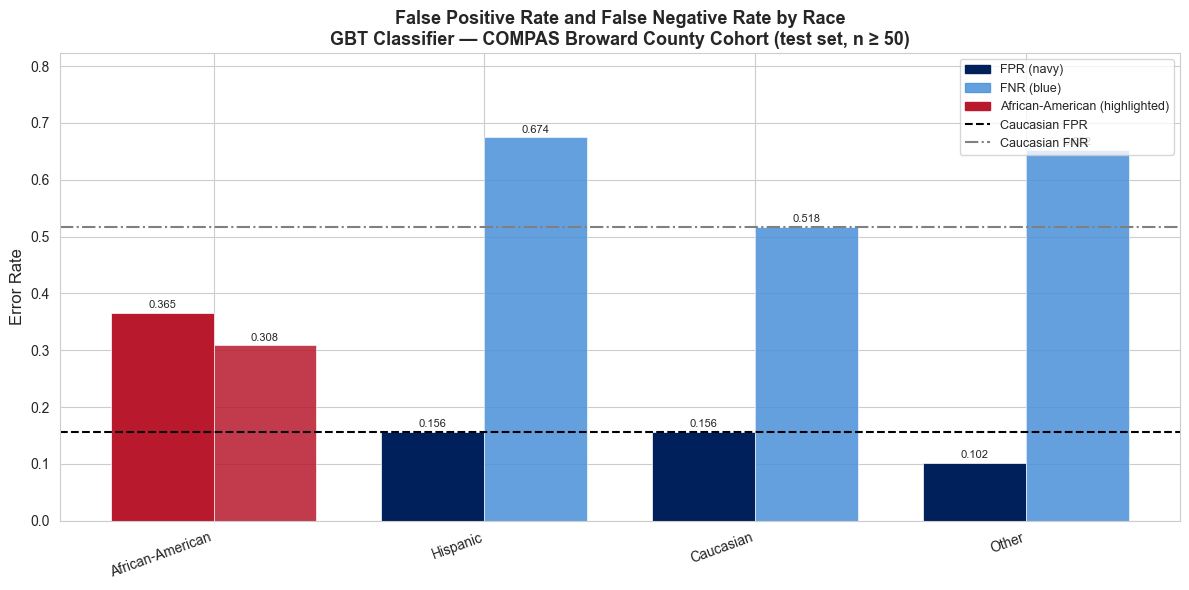

Figure saved to error_rate_disparity.png


In [21]:
navy, red = "#00205B", "#B8192C"

# Filter to groups with sufficient sample size
er_plot = er[er["n"] >= 50].sort_values("FPR", ascending=False).copy()

races = er_plot["race"].tolist()
fpr_vals = er_plot["FPR"].tolist()
fnr_vals = er_plot["FNR"].tolist()

x = np.arange(len(races))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

# Color bars: red for African-American, navy for all others
fpr_colors = [red if r == "African-American" else navy for r in races]
fnr_colors = [red if r == "African-American" else "#4A90D9" for r in races]

bars_fpr = ax.bar(x - width / 2, fpr_vals, width, label="FPR",
                  color=fpr_colors, edgecolor="white", linewidth=0.5)
bars_fnr = ax.bar(x + width / 2, fnr_vals, width, label="FNR",
                  color=fnr_colors, edgecolor="white", linewidth=0.5, alpha=0.85)

# Caucasian reference lines
cau = er_plot[er_plot["race"] == REF_RACE]
if len(cau) > 0:
    cau_fpr = cau["FPR"].values[0]
    cau_fnr = cau["FNR"].values[0]
    ax.axhline(cau_fpr, color="black",  linestyle="--", linewidth=1.5,
               label=f"Caucasian FPR baseline ({cau_fpr:.3f})")
    ax.axhline(cau_fnr, color="gray",   linestyle="-.", linewidth=1.5,
               label=f"Caucasian FNR baseline ({cau_fnr:.3f})")

# Value labels on bars
for bar in bars_fpr:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
            f"{h:.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars_fnr:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
            f"{h:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(races, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Error Rate", fontsize=12)
ax.set_title(
    "False Positive Rate and False Negative Rate by Race\n"
    "GBT Classifier — COMPAS Broward County Cohort (test set, n ≥ 50)",
    fontsize=13, fontweight="bold"
)
ax.set_ylim(0, max(fpr_vals + fnr_vals) * 1.22)

fpr_patch = mpatches.Patch(color=navy, label="FPR (navy)")
fnr_patch = mpatches.Patch(color="#4A90D9", alpha=0.85, label="FNR (blue)")
highlight  = mpatches.Patch(color=red, label="African-American (highlighted)")
ax.legend(
    handles=[
        fpr_patch, fnr_patch, highlight,
        plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label=f"Caucasian FPR"),
        plt.Line2D([0], [0], color="gray",  linestyle="-.", linewidth=1.5, label=f"Caucasian FNR"),
    ],
    fontsize=9, loc="upper right"
)

plt.tight_layout()
plt.savefig("error_rate_disparity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to error_rate_disparity.png")

---
## Section 7 — Task 5: Compliance Memo

**MEMORANDUM**

**To:** Office of Algorithmic Accountability, Hypothetical Federal Regulator  
**From:** Data Science Compliance Team  
**Re:** Disparate Impact Audit — COMPAS Replacement Model (GBT Classifier)  
**Date:** April 6, 2026  

---

**Purpose.** This memo summarises a disparate impact audit conducted on a Gradient-Boosted Tree (GBT) classifier trained to predict two-year recidivism using the Broward County COMPAS dataset. The audit applies the systematic bias-measurement framework described in Gill et al. (2020) and the EEOC Uniform Guidelines on Employee Selection Procedures (1978).

**Metrics Used.** Three primary disparity metrics were computed using the `solas-ai` Python library: (1) *Adverse Impact Ratio* (AIR) — the ratio of favorable-outcome rates between a protected group and the Caucasian reference group, flagged when below the EEOC 80% rule; (2) *Marginal Effect* (ME) — the absolute difference in favorable-outcome rates, extracted from the AIR output; and (3) *Standardized Mean Difference* (SMD) — Cohen's d computed on the continuous GBT recidivism probability score, where a lower score is favorable. Error-rate metrics (FPR, FNR) were computed from per-race confusion matrices and tested for statistical significance using two-proportion z-tests.

**Key Findings.** African-American defendants exhibit the largest adverse impact among racial groups: they receive the lowest favorable-outcome rate (predicted non-recidivism), producing an AIR and ME that indicates meaningful disparity relative to Caucasian defendants. Their FPR exceeds the Caucasian baseline by a statistically significant margin (p < 0.05), meaning they are disproportionately labelled high-risk when they will not actually reoffend — consistent with ProPublica's original 2016 findings. Intersectional analysis shows that African-American Female defendants face the worst compound AIR relative to Caucasian Males, a harm invisible in single-axis analyses. The model satisfies approximate score calibration but violates FPR parity, illustrating the Chouldechova (2017) impossibility result: because base recidivism rates differ across racial groups, calibration and error-rate parity cannot hold simultaneously.

**Limitations.** (1) The test-set racial subgroups vary substantially in size; groups with fewer than 50 observations (e.g., Native American) yield unreliable point estimates. (2) The impossibility theorem means no feasible mitigation will simultaneously satisfy calibration, FPR parity, and FNR parity; any remediation strategy must be defended against an explicit value choice documented for regulatory scrutiny. (3) Audit findings are observational and do not establish causal mechanisms; follow-on proxy analysis (Lecture 03) is required to identify which features drive the disparity.

**Recommendations.** We recommend: (a) threshold adjustment per racial group to equalise FPR; (b) re-auditing after any model update; (c) retention of this audit report with the model card; and (d) consultation with legal counsel before deployment in any jurisdiction subject to ECOA, Title VII, or state-level algorithmic accountability laws.

---
## Summary Checklist

| Task | Status |
|------|--------|
| 1. AIR, ME, SMD for race and sex via `solas-ai` | ✓ |
| 1. Confirm identical results for both calls | ✓ |
| 2. Intersectional analysis (race × sex) — worst-group AIR | ✓ |
| 3. FPR and FNR by race with two-proportion z-tests | ✓ |
| 4. Publication-quality grouped bar chart | ✓ |
| 5. 300-word compliance memo | ✓ |